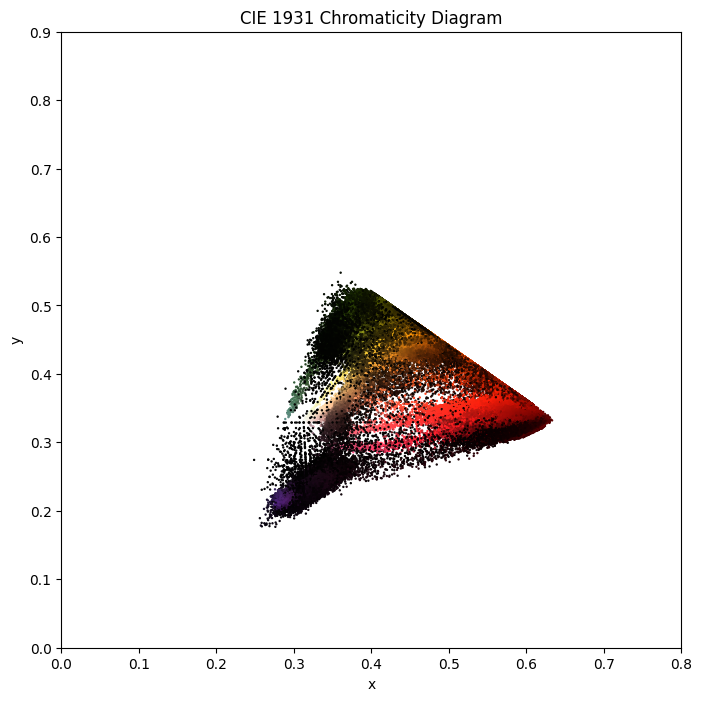

In [ ]:
"""List of Hands on Experiments: 
1. Plot the chromaticity coordinates of the pixels of an image on the CIE 1931 diagram. """
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

image_path = "peppers.png"
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
img = img / 255.0  

def srgb_to_linear(rgb):
    mask = rgb <= 0.04045
    linear = np.where(mask, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)
    return linear

linear_rgb = srgb_to_linear(img)

M = np.array([
    [0.4124564, 0.3575761, 0.1804375],
    [0.2126729, 0.7151522, 0.0721750],
    [0.0193339, 0.1191920, 0.9503041]
])

h, w, c = linear_rgb.shape
rgb_flat = linear_rgb.reshape(-1, 3)
xyz_flat = np.dot(rgb_flat, M.T)

X = xyz_flat[:, 0]
Y = xyz_flat[:, 1]
Z = xyz_flat[:, 2]

x = X / (X + Y + Z)
y = Y / (X + Y + Z)

cie_data = np.loadtxt("cie_1931_outline.csv", delimiter=",") 
plt.figure(figsize=(8, 8))
plt.plot(cie_data[:, 0], cie_data[:, 1], 'k')  
plt.scatter(x, y, c=np.clip(rgb_flat, 0, 1), s=0.5)  
plt.xlabel("x")
plt.ylabel("y")
plt.title("CIE 1931 Chromaticity Diagram")
plt.xlim(0, 0.8)
plt.ylim(0, 0.9)
plt.show()


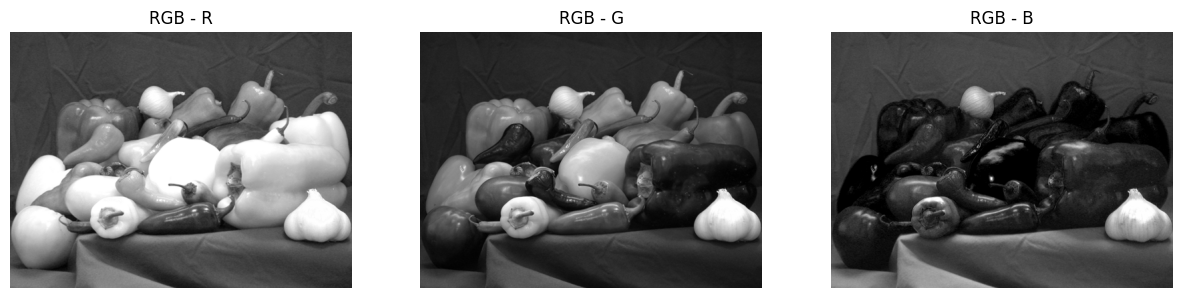

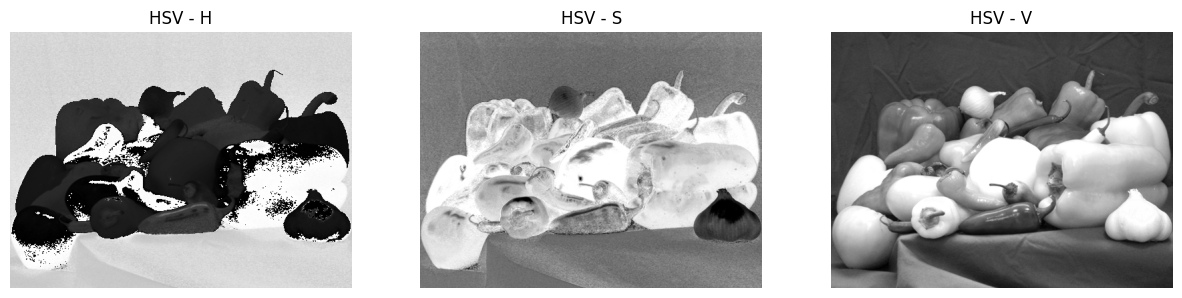

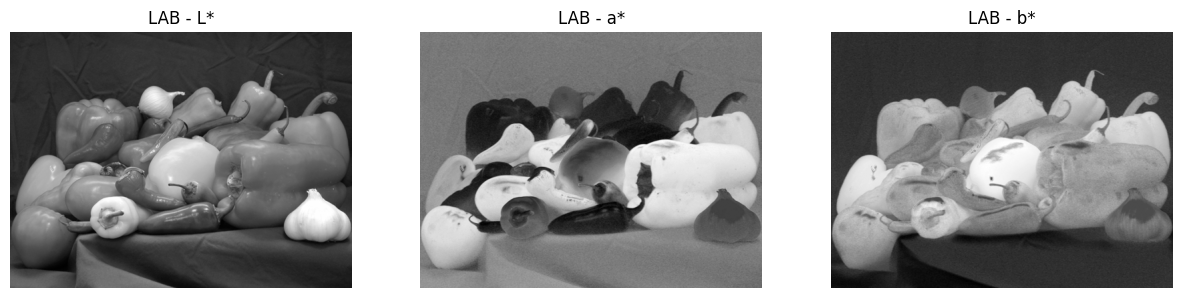

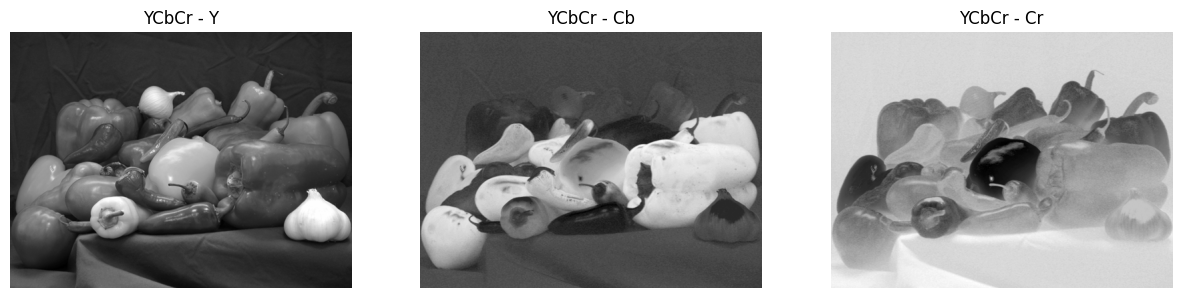

In [ ]:

#2. Analysis of images with different color models.
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "peppers.png"
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

def plot_channels(image, title, channels):
    plt.figure(figsize=(15,5))
    for i, channel in enumerate(channels):
        plt.subplot(1,3,i+1)
        plt.imshow(image[:,:,i], cmap='gray')
        plt.title(f'{title} - {channel}')
        plt.axis('off')
    plt.show()
\
plot_channels(img_rgb, "RGB", ["R","G","B"])
plot_channels(img_hsv, "HSV", ["H","S","V"])
plot_channels(img_lab, "LAB", ["L*","a*","b*"])
plot_channels(img_ycrcb, "YCbCr", ["Y","Cb","Cr"])


Mean LAB values of Image 1: [116. 186. 164.]
Mean LAB values of Image 2: [110. 177. 155.]


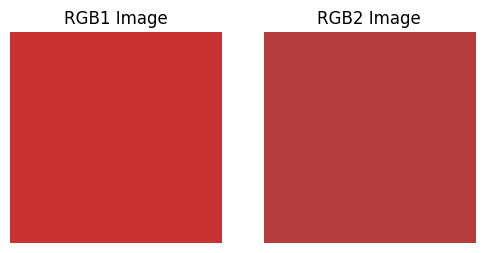

In [ ]:
#3. Create two synthetic images with different RGB values but perceptually similar when converted to LAB.
import cv2
import numpy as np
import matplotlib.pyplot as plt

rgb1 = np.array([200, 50, 50], dtype=np.uint8)  
rgb2 = np.array([180, 60, 60], dtype=np.uint8) 

img1 = np.ones((200, 200, 3), dtype=np.uint8) * rgb1
img2 = np.ones((200, 200, 3), dtype=np.uint8) * rgb2

img1_lab = cv2.cvtColor(img1, cv2.COLOR_RGB2LAB)
img2_lab = cv2.cvtColor(img2, cv2.COLOR_RGB2LAB)

mean_lab1 = np.mean(img1_lab.reshape(-1, 3), axis=0)
mean_lab2 = np.mean(img2_lab.reshape(-1, 3), axis=0)

print("Mean LAB values of Image 1:", mean_lab1)
print("Mean LAB values of Image 2:", mean_lab2)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("RGB1 Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("RGB2 Image")
plt.axis('off')

plt.show()




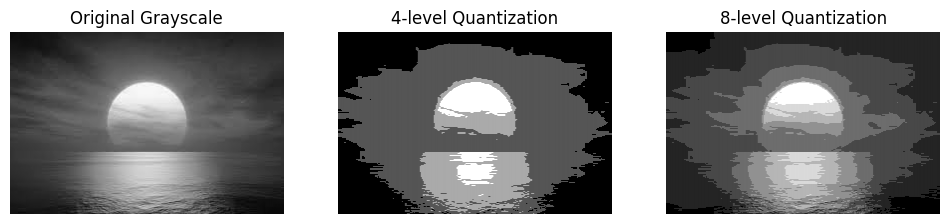

In [ ]:
#4. Perform gray-level and color image quantization.  
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_gray = cv2.imread("sunset.jpeg", cv2.IMREAD_GRAYSCALE)

def gray_quantization(img, levels):
    max_val = 255
    quantized = np.floor(img / (max_val / levels)) * (max_val / (levels - 1))
    return quantized.astype(np.uint8)

img_gray_4 = gray_quantization(img_gray, 4)
img_gray_8 = gray_quantization(img_gray, 8)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_gray_4, cmap='gray')
plt.title("4-level Quantization")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_gray_8, cmap='gray')
plt.title("8-level Quantization")
plt.axis('off')

plt.show()


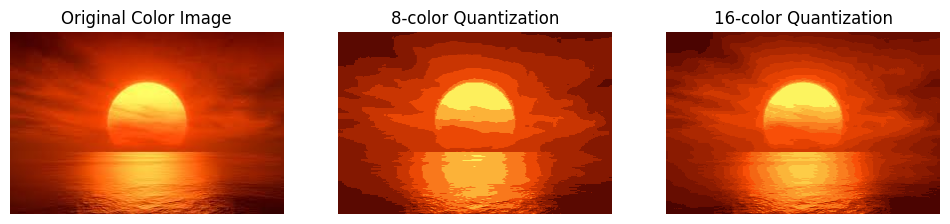

In [ ]:
from sklearn.cluster import KMeans

img_color = cv2.imread("sunset.jpeg")
img_color = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
h, w, c = img_color.shape

pixels = img_color.reshape(-1, 3)

def color_quantization(pixels, k):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)
    new_colors = kmeans.cluster_centers_[labels].astype(np.uint8)
    quantized_img = new_colors.reshape(h, w, 3)
    return quantized_img

img_color_8 = color_quantization(pixels, 8)
img_color_16 = color_quantization(pixels, 16)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_color)
plt.title("Original Color Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_color_8)
plt.title("8-color Quantization")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_color_16)
plt.title("16-color Quantization")
plt.axis('off')

plt.show()


C:\Users\donpr\AppData\Local\Temp\ipykernel_7148\728567390.py:53: RuntimeWarning: invalid value encountered in power
  srgb = np.where(mask, linear * 12.92, 1.055 * (linear ** (1/2.4)) - 0.055)


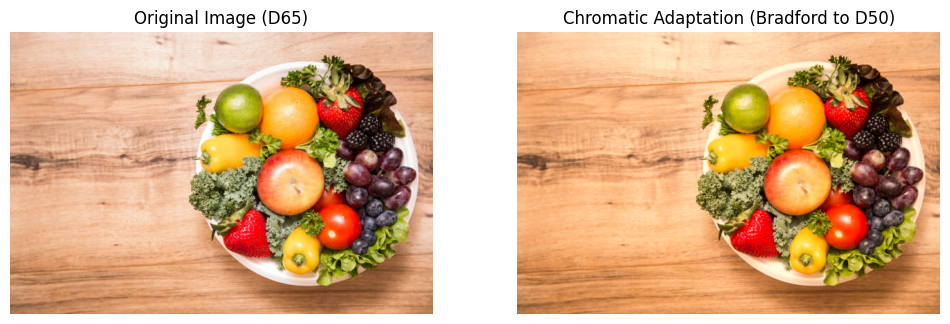

In [ ]:
#5. Apply chromatic adaptation transform (Bradford or von Kries) on industrial images to demonstrate constancy.
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("fruitbasket.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0 

source_wp = np.array([0.95047, 1.00000, 1.08883])
target_wp = np.array([0.96422, 1.00000, 0.82521])

def srgb_to_linear(rgb):
    mask = rgb <= 0.04045
    return np.where(mask, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)

linear_rgb = srgb_to_linear(img_rgb)

M_rgb2xyz = np.array([[0.4124564, 0.3575761, 0.1804375],
                      [0.2126729, 0.7151522, 0.0721750],
                      [0.0193339, 0.1191920, 0.9503041]])
img_xyz = linear_rgb @ M_rgb2xyz.T

M_br = np.array([[0.8951, 0.2664, -0.1614],
                 [-0.7502, 1.7135, 0.0367],
                 [0.0389, -0.0685, 1.0296]])

cone_src = M_br @ source_wp
cone_tar = M_br @ target_wp

D = np.diag(cone_tar / cone_src)

img_xyz_flat = img_xyz.reshape(-1, 3).T
adapted_xyz = np.linalg.inv(M_br) @ D @ (M_br @ img_xyz_flat)
adapted_xyz = adapted_xyz.T.reshape(img_xyz.shape)

M_xyz2rgb = np.linalg.inv(M_rgb2xyz)
img_lin_rgb_adapted = adapted_xyz @ M_xyz2rgb.T

def linear_to_srgb(linear):
    mask = linear <= 0.0031308
    srgb = np.where(mask, linear * 12.92, 1.055 * (linear ** (1/2.4)) - 0.055)
    return np.clip(srgb, 0, 1)

img_srgb_adapted = linear_to_srgb(img_lin_rgb_adapted)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original Image (D65)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_srgb_adapted)
plt.title("Chromatic Adaptation (Bradford to D50)")
plt.axis('off')
plt.show()


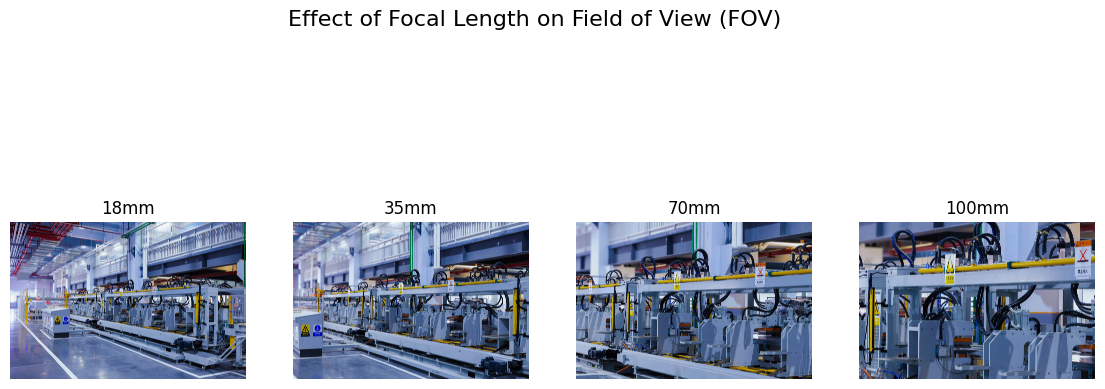

Approximate Field of View (FOV) for each focal length:

Focal Length: 18 mm  →  FOV ≈ 90.00°
Focal Length: 35 mm  →  FOV ≈ 54.43°
Focal Length: 70 mm  →  FOV ≈ 28.84°
Focal Length: 100 mm  →  FOV ≈ 20.41°


In [ ]:
#6. Capture images at different focal lengths to analyze FOV changes.  
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

image_path = "scene.jpg"
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError("Image not found. Please download and save as 'scene.jpg' in the same folder.")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def simulate_zoom(image, zoom_factor):
    h, w = image.shape[:2]
    new_h, new_w = int(h / zoom_factor), int(w / zoom_factor)
    y1 = (h - new_h) // 2
    x1 = (w - new_w) // 2
    cropped = image[y1:y1 + new_h, x1:x1 + new_w]
    zoomed = cv2.resize(cropped, (w, h))
    return zoomed

zoom_levels = [1.0, 1.5, 2.5, 4.0]  
focal_lengths = [18, 35, 70, 100]  
sensor_width = 36  

zoomed_images = [simulate_zoom(img, z) for z in zoom_levels]

plt.figure(figsize=(14, 6))
for i, zoomed in enumerate(zoomed_images):
    plt.subplot(1, len(zoomed_images), i + 1)
    plt.imshow(zoomed)
    plt.title(f"{focal_lengths[i]}mm")
    plt.axis("off")

plt.suptitle("Effect of Focal Length on Field of View (FOV)", fontsize=16)
plt.show()

print("Approximate Field of View (FOV) for each focal length:\n")
for f in focal_lengths:
    fov = 2 * math.degrees(math.atan(sensor_width / (2 * f)))
    print(f"Focal Length: {f} mm  →  FOV ≈ {fov:.2f}°")


Detected pixel diameter: 366.00 px
Estimated pixel resolution: 0.0656 mm/pixel
Approximate Near Limit: 48.41 cm
Approximate Far Limit: 51.70 cm
Depth of Field (DOF): 3.30 cm


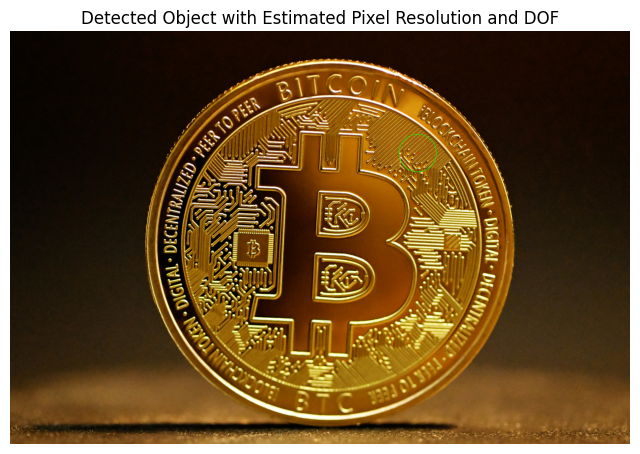

In [ ]:
#7. Estimate pixel resolution using known object dimensions to compute DOF. 
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = "coin.jpg"  
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError("Image not found. Please download and rename to 'coin.jpg'.")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (7, 7), 2)

circles = cv2.HoughCircles(
    gray_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
    param1=100, param2=30, minRadius=20, maxRadius=200
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :1]: 
        cv2.circle(img_rgb, (x, y), r, (0, 255, 0), 3)
        cv2.rectangle(img_rgb, (x - 5, y - 5), (x + 5, y + 5), (255, 0, 0), -1)
        detected_radius_px = r
else:
    raise ValueError("No circular object detected. Try adjusting lighting or image.")

known_diameter_mm = 24.0  
pixel_diameter = detected_radius_px * 2
pixel_resolution = known_diameter_mm / pixel_diameter  

print(f"Detected pixel diameter: {pixel_diameter:.2f} px")
print(f"Estimated pixel resolution: {pixel_resolution:.4f} mm/pixel")

focal_length_mm = 50.0
f_number = 2.8
subject_distance_mm = 500.0 
coc_mm = pixel_resolution  

H = (focal_length_mm ** 2) / (f_number * coc_mm) + focal_length_mm

Dn = (H * subject_distance_mm) / (H + (subject_distance_mm - focal_length_mm))
Df = (H * subject_distance_mm) / (H - (subject_distance_mm - focal_length_mm))
DOF = Df - Dn

print(f"Approximate Near Limit: {Dn/10:.2f} cm")
print(f"Approximate Far Limit: {Df/10:.2f} cm")
print(f"Depth of Field (DOF): {DOF/10:.2f} cm")

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Detected Object with Estimated Pixel Resolution and DOF")
plt.axis("off")
plt.show()


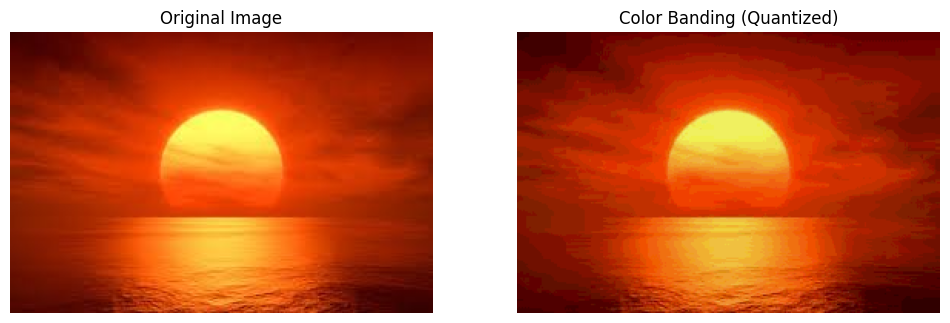

In [ ]:
"""List of Assignments to be given:
2. Analyze two real-world examples where improper calibration or quantization causes 
visible artifacts."""
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("sunset.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_band = np.floor(img / 16) * 16
img_band = img_band.astype(np.uint8)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_band)
plt.title("Color Banding (Quantized)")
plt.axis('off')
plt.show()


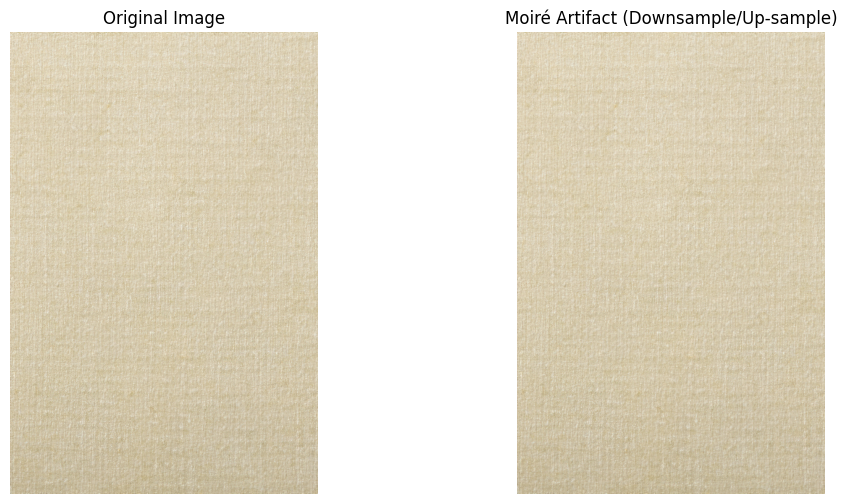

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("fabric1.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

factor = 4 
h, w = img.shape[:2]
img_small = cv2.resize(img, (w//factor, h//factor), interpolation=cv2.INTER_AREA)
img_moire = cv2.resize(img_small, (w, h), interpolation=cv2.INTER_NEAREST)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_moire)
plt.title("Moiré Artifact (Downsample/Up-sample)")
plt.axis('off')
plt.show()


In [ ]:
"""3.Obtain or simulate an industrial dataset (e.g., machine parts, PCB boards, mechanical 
tools) captured under: Different lighting conditions (bright, dim, directional, uneven 
illumination) and Different lens parameters (focal length, aperture, exposure time)."""
import cv2
import numpy as np
import os

def adjust_brightness(img, factor):

    return np.clip(img * factor, 0, 255).astype(np.uint8)

def add_directional_light(img, direction='left'):

    h, w = img.shape[:2]
    if direction in ['left','right']:
        gradient = np.linspace(0.5, 1.5, w)
        if direction == 'right':
            gradient = gradient[::-1]
        grad = np.tile(gradient, (h,1))
    else:  # top/bottom
        gradient = np.linspace(0.5, 1.5, h)
        if direction == 'bottom':
            gradient = gradient[::-1]
        grad = np.tile(gradient[:, np.newaxis], (1, w))
    grad = np.expand_dims(grad, axis=2)
    return np.clip(img * grad, 0, 255).astype(np.uint8)

def add_uneven_light(img):

    h, w = img.shape[:2]
    X, Y = np.meshgrid(np.linspace(-1,1,w), np.linspace(-1,1,h))
    sigma = 0.5
    mask = np.exp(-(X**2 + Y**2)/(2*sigma**2))
    mask = mask / mask.max() * 1.5
    return np.clip(img * mask[:,:,np.newaxis], 0, 255).astype(np.uint8)

def simulate_zoom(img, zoom_factor=1.2):
\
    h, w = img.shape[:2]
    new_h, new_w = int(h/zoom_factor), int(w/zoom_factor)
    crop_img = img[h//2-new_h//2:h//2+new_h//2, w//2-new_w//2:w//2+new_w//2]
    return cv2.resize(crop_img, (w,h))

def simulate_dof(img, blur_strength=5):

    return cv2.GaussianBlur(img, (blur_strength*2+1, blur_strength*2+1), 0)

def simulate_motion_blur(img, size=15):

    kernel = np.zeros((size, size))
    kernel[int((size-1)/2), :] = np.ones(size)
    kernel /= size
    return cv2.filter2D(img, -1, kernel)

# ----------------- Main Dataset Simulation ----------------- #
base_folder = "industrial_images"      # Folder with base images
output_folder = "simulated_dataset"    # Folder to save variations
os.makedirs(output_folder, exist_ok=True)

# Process each image
for filename in os.listdir(base_folder):
    if filename.lower().endswith((".png", ".jpg", ".jpeg")):
        img_path = os.path.join(base_folder, filename)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Apply lighting variations
        bright = adjust_brightness(img, 1.5)
        dim = adjust_brightness(img, 0.5)
        directional = add_directional_light(img, 'left')
        uneven = add_uneven_light(img)

        # Apply lens variations
        zoom = simulate_zoom(img, 1.2)
        dof = simulate_dof(img, 7)
        motion = simulate_motion_blur(img, 15)

        # Save all variations
        variations = {
            "bright": bright,
            "dim": dim,
            "directional": directional,
            "uneven": uneven,
            "zoom": zoom,
            "dof": dof,
            "motion": motion
        }

        for var_name, var_img in variations.items():
            save_path = os.path.join(output_folder, f"{os.path.splitext(filename)[0]}_{var_name}.png")
            cv2.imwrite(save_path, cv2.cvtColor(var_img, cv2.COLOR_RGB2BGR))

print("Simulation completed! Variations saved in 'simulated_dataset/' folder.")


Simulation completed! Variations saved in 'simulated_dataset/' folder.
